In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

1.	Read the CSV file using pandas. 
2.	Identify: 
o	missing values 
o	duplicate records 
o	invalid sales values 
3.	Replace missing Sales with mean. 
4.	Replace missing Profit with median. 
5.	Remove duplicate rows. 
6.	Convert OrderDate into datetime format. 
7.	Standardize City names into uppercase. 
8.	Detect outliers in Sales using IQR. 

In [34]:
df = pd.read_csv("retail.csv")
display(df)

,OrderID,CustomerName,Product,Category,City,Sales,Quantity,Discount,Profit,OrderDate,Feedback
0,1001,Asha,Keyboard,Electronics,Bangalore,1500.0,2,10,300.0,1/10/2024,Excellent product
1,1002,Ravi,Mouse,Electronics,Mysore,800.0,1,5,120.0,1/11/2024,Good quality
2,1003,Priya,Notebook,Stationery,Bangalore,200.0,5,0,50.0,1/12/2024,Very useful
3,1004,Kiran,Pen,Stationery,Mangalore,100.0,10,0,30.0,1/13/2024,Good
4,1005,Anu,Headphones,Electronics,Hubli,2500.0,1,15,400.0,1/14/2024,Sound is amazing
5,1006,Manoj,Chair,Furniture,Bangalore,3500.0,1,20,500.0,1/15/2024,Comfortable chair
6,1007,Sneha,Desk,Furniture,Mysore,4500.0,1,10,700.0,1/16/2024,Strong and durable
7,1008,Rahul,Laptop Stand,Electronics,Bangalore,1200.0,2,5,200.0,1/17/2024,Useful accessory
8,1009,Divya,Marker,Stationery,Hubli,150.0,6,0,40.0,1/18/2024,Good markers
9,1010,Vijay,Table,Furniture,Mangalore,5000.0,1,25,900.0,1/19/2024,Very sturdy


In [35]:
df['Sales'].fillna(df['Sales'].mean(), inplace=True)
df['Profit'].fillna(df['Profit'].median(), inplace=True)

C:\Users\CDAC\AppData\Local\Temp\ipykernel_3608\819710723.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Sales'].fillna(df['Sales'].mean(), inplace=True)
C:\Users\CDAC\AppData\Local\Temp\ipykernel_3608\819710723.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [36]:
# df['OrderDate'].astype('datetime')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

In [37]:
df['City'] = df['City'].apply(lambda x: x.upper())

In [45]:
q1 = df['Sales'].quantile(0.25)
q3 = df['Sales'].quantile(0.75)

iqr = q3-q1

high = q3 + 1.5*iqr
low = q1 - 1.5*iqr

df.loc[(df['Sales']<low) | (df['Sales']>high), 'Sales'] = df['Sales'].median()

1.	Create a bar chart showing total sales by category. 
2.	Create a line chart showing daily sales trend. 
3.	Create a pie chart showing city-wise order distribution. 
4.	Create a boxplot for Sales across categories. 
5.	Create a count plot for orders per city. 

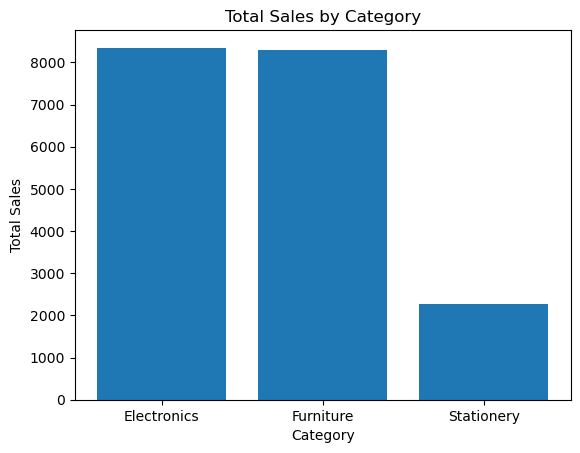

In [67]:
cat_counts = df[['Category', 'Sales']].groupby('Category').sum()

plt.bar(cat_counts.index, cat_counts['Sales'])
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.title('Total Sales by Category')
plt.show()

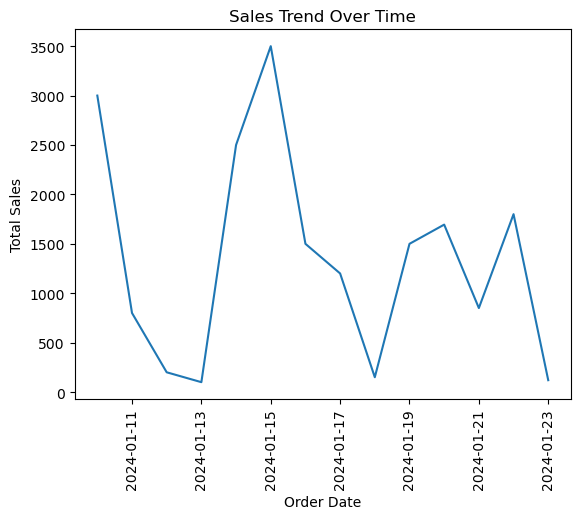

In [75]:
date_sales = df[['OrderDate', 'Sales']].groupby('OrderDate').sum()
plt.plot(date_sales.index, date_sales['Sales'])
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.title('Sales Trend Over Time')
plt.xticks(rotation=90)
plt.show()

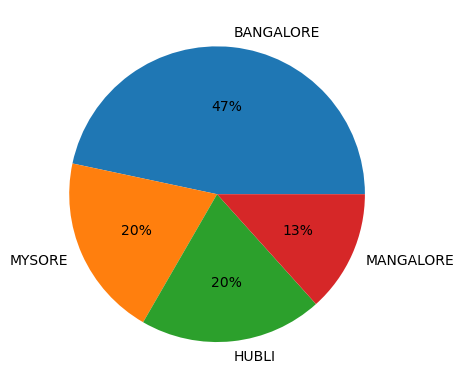

In [91]:
city_distribution = df['City'].value_counts()
plt.pie(city_distribution, labels=city_distribution.index, autopct='%.0f%%')
plt.show()

In [69]:
plt.plot?

Signature:
plt.plot(
    *args: 'float | ArrayLike | str',
    scalex: 'bool' = True,
    scaley: 'bool' = True,
    data=None,
    **kwargs,
) -> 'list[Line2D]'
Docstring:
Plot y versus x as lines and/or markers.

Call signatures::

    plot([x], y, [fmt], *, data=None, **kwargs)
    plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

The coordinates of the points or line nodes are given by *x*, *y*.

The optional parameter *fmt* is a convenient way for defining basic
formatting like color, marker and linestyle. It's a shortcut string
notation described in the *Notes* section below.

>>> plot(x, y)        # plot x and y using default line style and color
>>> plot(x, y, 'bo')  # plot x and y using blue circle markers
>>> plot(y)           # plot y using x as index array 0..N-1
>>> plot(y, 'r+')     # ditto, but with red plusses

You can use `.Line2D` properties as keyword arguments for more
control on the appearance. Line properties and *fmt* can be mixed.
The following two calls yie

In [61]:
cat_df['Category'].index

AttributeError: 'SeriesGroupBy' object has no attribute 'index'

In [46]:
display(df)

,OrderID,CustomerName,Product,Category,City,Sales,Quantity,Discount,Profit,OrderDate,Feedback
0,1001,Asha,Keyboard,Electronics,BANGALORE,1500.000000,2,10,300.0,2024-01-10,Excellent product
1,1002,Ravi,Mouse,Electronics,MYSORE,800.000000,1,5,120.0,2024-01-11,Good quality
2,1003,Priya,Notebook,Stationery,BANGALORE,200.000000,5,0,50.0,2024-01-12,Very useful
3,1004,Kiran,Pen,Stationery,MANGALORE,100.000000,10,0,30.0,2024-01-13,Good
4,1005,Anu,Headphones,Electronics,HUBLI,2500.000000,1,15,400.0,2024-01-14,Sound is amazing
5,1006,Manoj,Chair,Furniture,BANGALORE,3500.000000,1,20,500.0,2024-01-15,Comfortable chair
6,1007,Sneha,Desk,Furniture,MYSORE,1500.000000,1,10,700.0,2024-01-16,Strong and durable
7,1008,Rahul,Laptop Stand,Electronics,BANGALORE,1200.000000,2,5,200.0,2024-01-17,Useful accessory
8,1009,Divya,Marker,Stationery,HUBLI,150.000000,6,0,40.0,2024-01-18,Good markers
9,1010,Vijay,Table,Furniture,MANGALORE,1500.000000,1,25,900.0,2024-01-19,Very sturdy
